In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
data = "https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv"

In [3]:
!wget $data

--2026-09-30 14:23:39--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 635180 (620K) [text/plain]
Saving to: ‘car_fuel_efficiency_2026.csv’

car_fuel_efficiency 100%[===================>] 620.29K  --.-KB/s    in 0.06s   

2026-09-30 14:23:40 (10.4 MB/s) - ‘car_fuel_efficiency_2026.csv’ saved [635180/635180]



In [4]:
df = pd.read_csv(data)

In [33]:
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [6]:
base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']

In [8]:
new_df = df[base]

In [9]:
new_df

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0
...,...,...,...,...,...
9995,2470,271.0,4690,2005,27.4
9996,2300,244.0,4370,1993,30.0
9997,2480,267.0,4590,2014,28.1
9998,2180,270.0,4450,2004,32.2


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

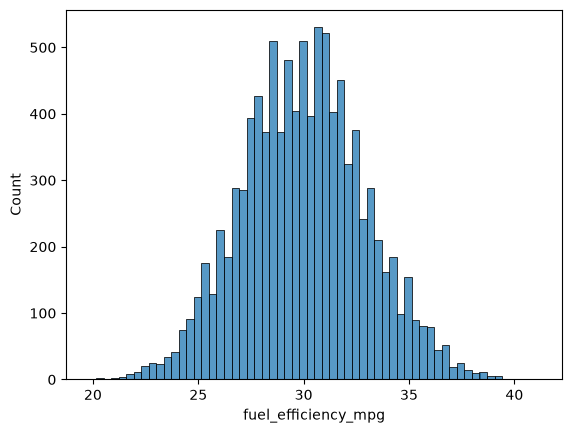

In [14]:
sns.histplot(new_df.fuel_efficiency_mpg)

In [15]:
new_df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [16]:
new_df.horsepower.median()

np.float64(254.0)

In [19]:
new_df.horsepower.head(50)

0     243.0
1     272.0
2     267.0
3     258.0
4     304.0
5     266.0
6     250.0
7     279.0
8     251.0
9     280.0
10      NaN
11    250.0
12      NaN
13    277.0
14    202.0
15    226.0
16    234.0
17    299.0
18    264.0
19    251.0
20    260.0
21    291.0
22    246.0
23    302.0
24    258.0
25    249.0
26    254.0
27    265.0
28    249.0
29    216.0
30    294.0
31    240.0
32      NaN
33    255.0
34    273.0
35    277.0
36    264.0
37    254.0
38    258.0
39      NaN
40    270.0
41    262.0
42    296.0
43    239.0
44    248.0
45    282.0
46      NaN
47      NaN
48    238.0
49      NaN
Name: horsepower, dtype: float64

In [20]:
new_df.horsepower.mean()

np.float64(254.44601556505535)

In [86]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

In [117]:
# np.random.seed(42)
np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

In [118]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train: n_train+ n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [119]:
df_train = df_train.reset_index(drop = True)
df_val = df_val.reset_index(drop = True)
df_test = df_test.reset_index(drop = True)

In [120]:
len(df_train), len(df_val), len(df_test)

(6000, 2000, 2000)

In [121]:
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

In [122]:
n

10000

In [123]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [124]:
df_train.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration
0,2014,USA,Gasoline,Front-wheel drive,3,2320,6,246.0,4100,19.0
1,1998,Europe,Diesel,Rear-wheel drive,4,2230,6,252.0,4250,NaN
2,2008,Europe,Gasoline,Front-wheel drive,3,2700,6,276.0,4490,17.8
3,2004,USA,Gasoline,Front-wheel drive,2,2220,7,269.0,4060,20.0
4,1979,USA,Gasoline,All-wheel drive,3,2370,6,NaN,4690,22.0


In [95]:
# df.head()

In [96]:
base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']
X_train = df_train[base].values


In [97]:
X_train

array([[1900.,  239., 3790., 2015.],
       [2000.,  224., 4380., 1992.],
       [2330.,  286., 4090., 2022.],
       ...,
       [2240.,  255., 4190., 1989.],
       [2430.,  254., 4280., 2020.],
       [2390.,  266., 4220., 1996.]], shape=(6000, 4))

In [98]:
y_train

array([32.5, 29.1, 34.1, ..., 27.7, 31.6, 28. ], shape=(6000,))

In [99]:
def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [100]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [101]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [102]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)
X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred).round(3)

np.float64(2.205)

In [103]:
y_pred

array([31.64502134, 29.86572978, 31.58838899, ..., 30.53133298,
       30.75085098, 31.62912778], shape=(2000,))

In [104]:
np.expm1(y_pred[0])

np.float64(55367911941944.84)

In [105]:
m = df_train.horsepower.mean()
def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(m)
    X = df_num.values
    return X

In [106]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)
X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred).round(3)

np.float64(2.202)

In [107]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [108]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=0.01)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(2.2017619547150615)

In [109]:
for r in [0.0, 0.01, 0.1, 1, 5, 10, 100]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred).round(4)
    
    print(r, w0, score)

0.0 -153.29645639114293 2.2018
0.01 -148.3339400973682 2.2018
0.1 -114.8674998355104 2.2156
1 -35.277026964220994 2.3442
5 -8.647363005749936 2.4145
10 -4.449162945750137 2.4268
100 -0.4568381300368677 2.4386


In [110]:
scores = []
for st in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    np.random.seed(st)
    idx = np.arange(n)
    np.random.shuffle(idx)
    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train: n_train+ n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]
    
    df_train = df_train.reset_index(drop = True)
    df_val = df_val.reset_index(drop = True)
    df_test = df_test.reset_index(drop = True)
    
    # y_train = np.log1p(df_train.fuel_efficiency_mpg.values)
    # y_val = np.log1p(df_val.fuel_efficiency_mpg.values)
    # y_test = np.log1p(df_test.fuel_efficiency_mpg.values)

    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values
    y_test = df_test.fuel_efficiency_mpg.values
    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']

    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=0.01)
    
    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)
    scores.append(rmse(y_val, y_pred))
    # print(np.std(scores).round(3))

In [111]:
scores

[np.float64(2.237090705480905),
 np.float64(2.1964823275775287),
 np.float64(2.1585332041695553),
 np.float64(2.2045881667117304),
 np.float64(2.1970959135995507),
 np.float64(2.2413917898695153),
 np.float64(2.2640685068627366),
 np.float64(2.185774623138563),
 np.float64(2.2179000485561056),
 np.float64(2.2036263152453865)]

In [85]:
np.std(scores).round(3)

np.float64(0.029)

In [125]:
def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [126]:
df_full_train = pd.concat([df_train, df_val])

In [127]:
df_full_train = df_full_train.reset_index(drop=True)

In [128]:
X_full_train = prepare_X(df_full_train)

In [129]:
y_full_train = np.concatenate([y_train, y_val])

In [130]:
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

In [131]:
X_test = prepare_X(df_test)
y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)
score

np.float64(2.235827747191731)